# HK Eda – skärmtid, sömn och mental hälsa

I den här notebooken gör vi en enkel, stegvis analys av datan i `screen_time_mental_health.csv`,
som innehåller uppgifter om ungdomars skärmtid, sömn och depressionsymtom.

**Viktigt om BDI:** kolumnen `bdi_total` är en poäng från ett standardiserat frågeformulär
(Beck Depression Inventory). Det är alltså ett självrapporterat mått – *inte* ett värde som
är uträknat från de andra kolumnerna i tabellen.

**Upplägg:** vi delar alltid upp datan i två segment – ett för flickor och ett för pojkar –
och gör samma analys för båda:

1. Ladda in datan
2. Övergripande koll
3. Dela upp i flickor och pojkar
4. Flickor: beskrivande statistik och grafer
5. Pojkar: beskrivande statistik och grafer
6. Jämförelse mellan flickor och pojkar
7. Förbered maskininlärning
8. Modell för flickor
9. Modell för pojkar
10. Test av polynomial regression
11. Slutsatser

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures  # extra utöver listan: behövs för polynomialtestet i steg 10
from sklearn.impute import SimpleImputer

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

## Steg 1: Ladda in datan

Filen ligger i `backend/`-mappen, så vi läser den med en relativ sökväg från den här notebooken.

In [2]:
CSV_PATH = "../backend/screen_time_mental_health.csv"
df = pd.read_csv(CSV_PATH)
df.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


## Steg 2: Övergripande koll av datan

Innan vi delar upp datan kollar vi storlek och om det finns saknade värden.

| Kolumn | Betydelse |
|---|---|
| `subject_id` | Personens id (används inte i analysen) |
| `sex` | Kön: `Girl` eller `Boy` – grunden för våra två segment |
| `screen_time_index` | Sammanvägt index för skärmtid |
| `est_leisure_screen_hours` | Uppskattad skärmtid på fritiden (timmar per dag) |
| `sleep_quality_index` | Index för sömnkvalitet (högre värde verkar betyda sämre sömn) |
| `avg_sleep_hours` | Snitt sovtimmar per natt |
| `midsleep_weekend_hours` | Mittpunkt för sömn på helgen (senare = mer förskjuten rytm) |
| `social_jetlag_hours` | Skillnad i sömn mellan vardag och helg |
| `bdi_total` | BDI-poäng från frågeformulär (0–51) – vår **målvariabel** |
| `depressed` | Binär markering (0/1) – lämnas utanför analysen |

In [3]:
print("Antal rader:  ", df.shape[0])
print("Antal kolumner:", df.shape[1])
print("Saknade värden per kolumn:")
df.isna().sum()

Antal rader:   4810
Antal kolumner: 10
Saknade värden per kolumn:


subject_id                  0
sex                         0
screen_time_index           0
est_leisure_screen_hours    0
sleep_quality_index         0
avg_sleep_hours             0
midsleep_weekend_hours      0
social_jetlag_hours         0
bdi_total                   0
depressed                   0
dtype: int64

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
subject_id,4810.0,2405.500000,1388.671727,1.00,1203.250,2405.50,3607.75,4810.00
screen_time_index,4810.0,3.219097,1.026348,1.00,2.333,3.00,4.00,6.00
est_leisure_screen_hours,4810.0,3.958299,2.387289,0.50,2.070,3.50,5.50,10.00
sleep_quality_index,4810.0,1.901611,0.851176,1.00,1.250,1.75,2.25,6.00
avg_sleep_hours,4810.0,7.689067,1.270213,1.36,7.050,7.87,8.54,12.21
midsleep_weekend_hours,4810.0,5.570553,1.415505,1.67,4.540,5.42,6.50,10.50
social_jetlag_hours,4810.0,2.400200,1.137931,-3.03,1.580,2.29,3.12,6.96
bdi_total,4810.0,7.271518,7.703156,0.00,2.000,5.00,10.00,51.00
depressed,4810.0,0.163617,0.369967,0.00,0.000,0.00,0.00,1.00


## Steg 3: Dela upp datan i flickor och pojkar

Vi skapar två separata tabeller – ett segment för flickor och ett för pojkar – och kör sedan
samma analys på båda. Vi definierar också vilka kolumner som är förklaringsvariabler
(skärm- och sömnvariablerna) och vilken som är målvariabeln (`bdi_total`).

In [5]:
FEATURES = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours",
]
TARGET = "bdi_total"

flickor = df[df["sex"] == "Girl"].copy()
pojkar = df[df["sex"] == "Boy"].copy()

print("Antal flickor:", flickor.shape[0])
print("Antal pojkar: ", pojkar.shape[0])

Antal flickor: 2364
Antal pojkar:  2446


## Steg 4: Flickor – beskrivande statistik och grafer

### a: Beskrivande statistik

Medelvärde, spridning (std), min/max och kvartiler för varje kolumn i flickorsegmentet.

In [6]:
flickor[FEATURES + [TARGET]].describe().T

,count,mean,std,min,25%,50%,75%,max
screen_time_index,2364.0,3.229946,1.013335,1.00,2.333,3.00,4.0000,6.00
est_leisure_screen_hours,2364.0,3.919666,2.329158,0.50,2.070,3.50,5.3600,10.00
sleep_quality_index,2364.0,2.078151,0.934735,1.00,1.500,1.75,2.5000,6.00
avg_sleep_hours,2364.0,7.588566,1.316214,1.36,6.940,7.82,8.4800,12.21
midsleep_weekend_hours,2364.0,5.445770,1.388396,1.67,4.460,5.25,6.2525,10.50
social_jetlag_hours,2364.0,2.310072,1.099693,-3.03,1.540,2.25,3.0000,6.75
bdi_total,2364.0,9.395093,8.705629,0.00,3.000,7.00,13.0000,51.00


### b: Fördelningar (histogram)

Histogram med en utjämnad trendkurva (`kde`) för varje variabel. Det visar var värdena ligger och om fördelningen är sned.

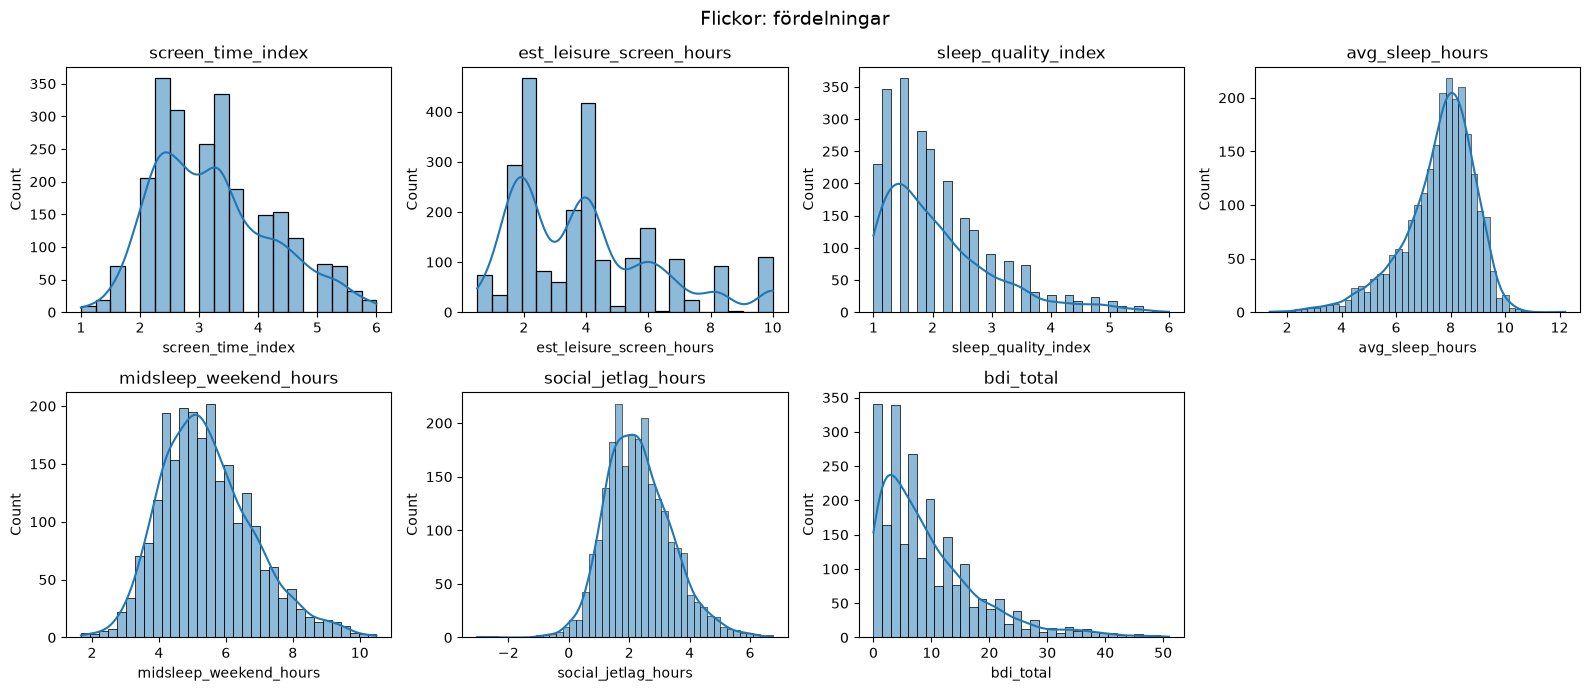

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, FEATURES + [TARGET]):
    sns.histplot(data=flickor, x=col, kde=True, ax=ax)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.suptitle("Flickor: fördelningar", fontsize=14)
plt.tight_layout()
plt.show()

### c: Korrelationsmatris

Värden nära **1** eller **-1** betyder starkt linjärt samband, värden nära **0** betyder inget samband. Vi är extra intresserade av raden/kolumnen för `bdi_total` – vilka variabler som hänger ihop med BDI-poängen.

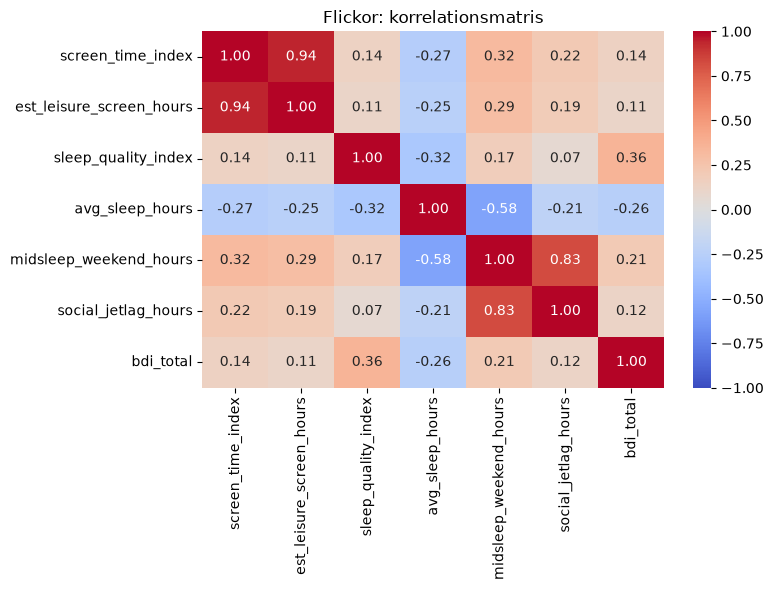

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(flickor[FEATURES + [TARGET]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Flickor: korrelationsmatris")
plt.tight_layout()
plt.show()

### d: Samband mot BDI

Spridningsdiagram med en enkel trendlinje för tre utvalda variabler mot `bdi_total`. En nästan horisontell linje betyder svagt samband.

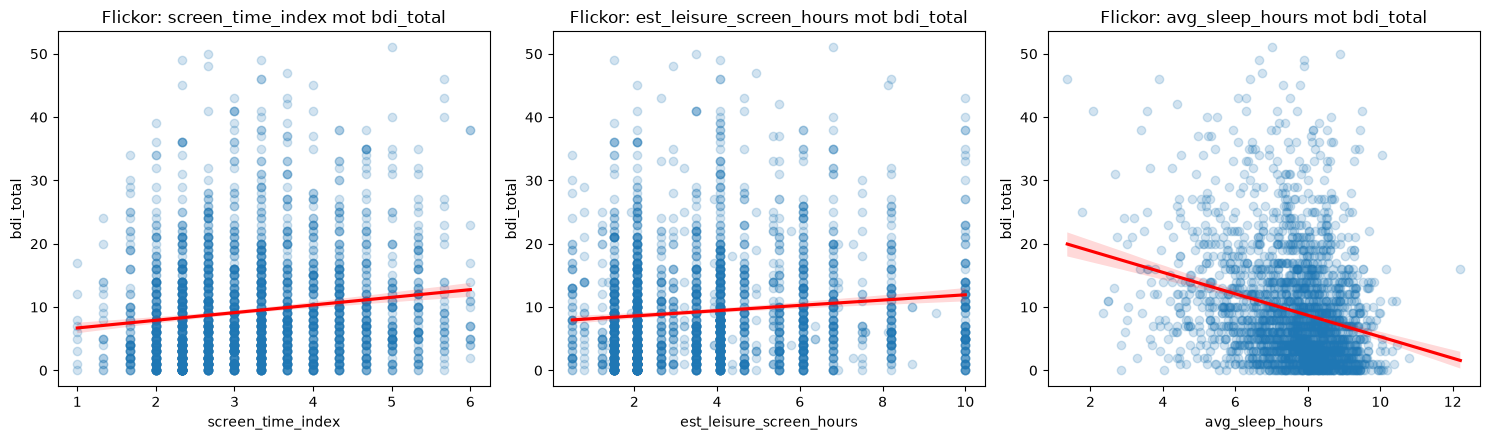

In [9]:
valda = ["screen_time_index", "est_leisure_screen_hours", "avg_sleep_hours"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, valda):
    sns.regplot(data=flickor, x=col, y=TARGET, ax=ax,
                scatter_kws={"alpha": 0.2}, line_kws={"color": "red"})
    ax.set_title(f"Flickor: {col} mot bdi_total")
plt.tight_layout()
plt.show()

## Steg 5: Pojkar – beskrivande statistik och grafer

Samma fyra steg som för flickorna, nu för pojksegmentet.

### a: Beskrivande statistik

Medelvärde, spridning (std), min/max och kvartiler för varje kolumn i pojkarsegmentet.

In [10]:
pojkar[FEATURES + [TARGET]].describe().T

,count,mean,std,min,25%,50%,75%,max
screen_time_index,2446.0,3.208612,1.038870,1.00,2.333,3.00,4.00,6.00
est_leisure_screen_hours,2446.0,3.995638,2.442053,0.50,2.070,3.50,5.50,10.00
sleep_quality_index,2446.0,1.730989,0.722022,1.00,1.250,1.50,2.00,6.00
avg_sleep_hours,2446.0,7.786198,1.216516,2.05,7.130,7.92,8.58,11.43
midsleep_weekend_hours,2446.0,5.691153,1.431199,1.88,4.620,5.58,6.67,10.25
social_jetlag_hours,2446.0,2.487306,1.167332,-1.00,1.670,2.42,3.25,6.96
bdi_total,2446.0,5.219133,5.906862,0.00,1.000,3.00,7.00,43.00


### b: Fördelningar (histogram)

Histogram med en utjämnad trendkurva (`kde`) för varje variabel. Det visar var värdena ligger och om fördelningen är sned.

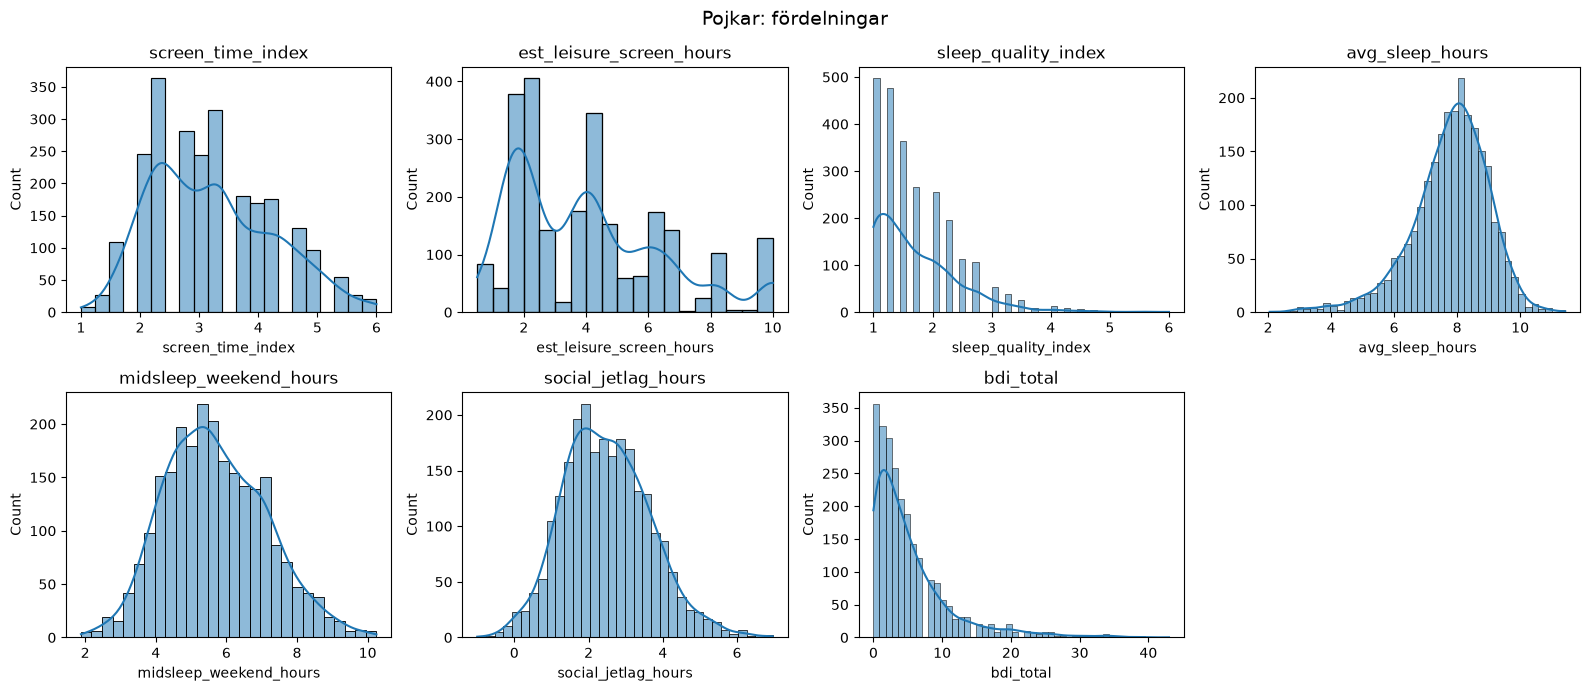

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, FEATURES + [TARGET]):
    sns.histplot(data=pojkar, x=col, kde=True, ax=ax)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.suptitle("Pojkar: fördelningar", fontsize=14)
plt.tight_layout()
plt.show()

### c: Korrelationsmatris

Värden nära **1** eller **-1** betyder starkt linjärt samband, värden nära **0** betyder inget samband. Vi är extra intresserade av raden/kolumnen för `bdi_total` – vilka variabler som hänger ihop med BDI-poängen.

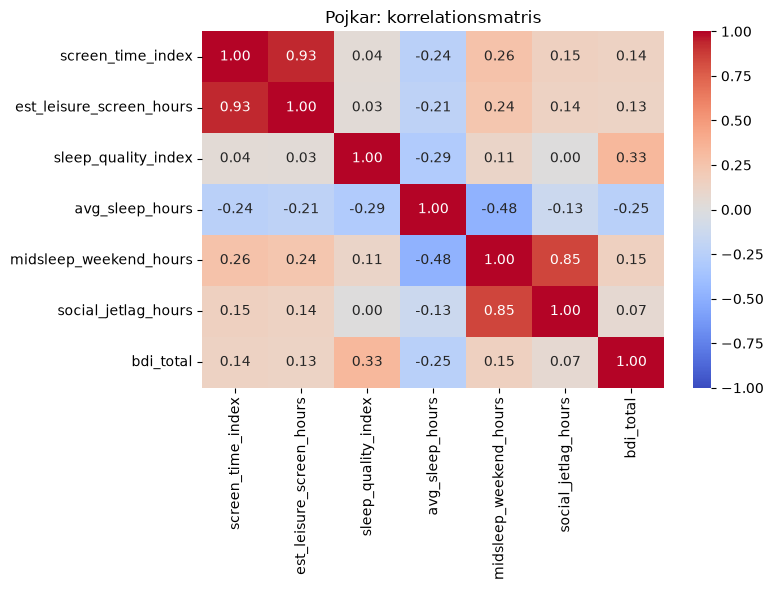

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(pojkar[FEATURES + [TARGET]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pojkar: korrelationsmatris")
plt.tight_layout()
plt.show()

### d: Samband mot BDI

Spridningsdiagram med en enkel trendlinje för tre utvalda variabler mot `bdi_total`. En nästan horisontell linje betyder svagt samband.

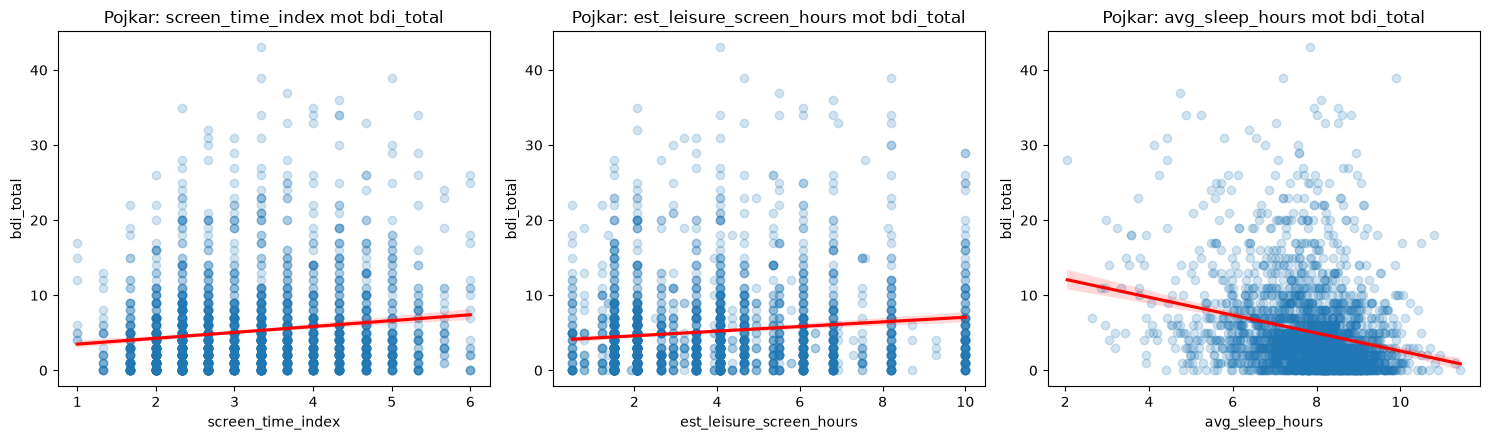

In [13]:
valda = ["screen_time_index", "est_leisure_screen_hours", "avg_sleep_hours"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, valda):
    sns.regplot(data=pojkar, x=col, y=TARGET, ax=ax,
                scatter_kws={"alpha": 0.2}, line_kws={"color": "red"})
    ax.set_title(f"Pojkar: {col} mot bdi_total")
plt.tight_layout()
plt.show()

## Steg 6: Jämförelse mellan flickor och pojkar

Vi ställer de två segmenten mot varandra – först medelvärden sida vid sida, sedan en lådplot
av BDI-poängen per kön för att se skillnad i nivå och spridning.

In [14]:
jamforelse = (df.groupby("sex")[FEATURES + [TARGET]].mean()
               .rename(index={"Boy": "Pojkar", "Girl": "Flickor"})
               .reindex(["Flickor", "Pojkar"])
               .round(2))
jamforelse

,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total
sex,,,,,,,
Flickor,3.23,3.92,2.08,7.59,5.45,2.31,9.40
Pojkar,3.21,4.00,1.73,7.79,5.69,2.49,5.22


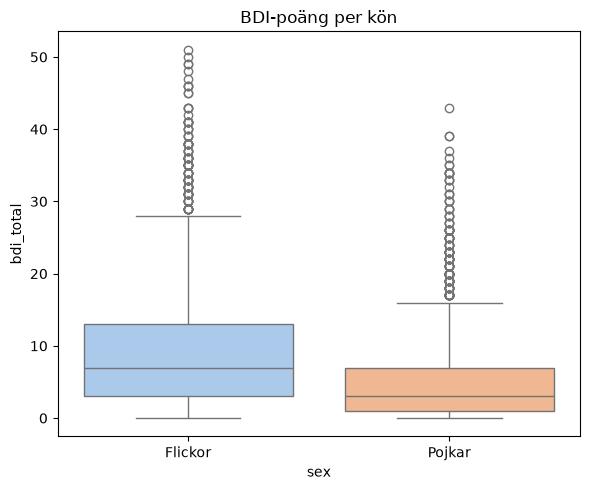

In [15]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="sex", y=TARGET, order=["Girl", "Boy"],
            hue="sex", hue_order=["Girl", "Boy"], palette="pastel", legend=False)
plt.xticks([0, 1], ["Flickor", "Pojkar"])
plt.title("BDI-poäng per kön")
plt.tight_layout()
plt.show()

## Steg 7: Förbered maskininlärning

Nu tittar vi på hur väl skärm- och sömnvariablerna kan förklara `bdi_total`. Vi samlar allt i en
funktion som vi sedan kör en gång per segment. Funktionen gör fyra saker:

1. **Dela upp** datan i tränings- och testdata (80/20).
2. **Pipeline** med imputering (fyller ev. saknade värden med medianen), skalning
   (`StandardScaler`) och en plats för modellen.
3. **`GridSearchCV`** med 5-fold korsvalidering som prövar tre modelltyper: linjär regression,
   beslutsträd och random forest – och väljer den bästa.
4. **Utvärdera** den bästa modellen på testdata med RMSE, MAE och MSE, samt en plot av
   prediktion mot verklighet (punkter nära den röda linjen = bra prediktioner).

In [16]:
RANDOM_STATE = 42

def train_and_evaluate(X, y, namn):
    """Träna och utvärdera modeller för ett segment (flickor eller pojkar)."""
    # 1. Dela upp i tränings- och testdata
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    # 2. Pipeline: imputering + skalning + modell
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

    # 3. Sök över tre modelltyper
    param_grid = [
        {"model": [LinearRegression()]},
        {"model": [DecisionTreeRegressor(random_state=RANDOM_STATE)],
         "model__max_depth": [3, 5, 10, None]},
        {"model": [RandomForestRegressor(random_state=RANDOM_STATE)],
         "model__n_estimators": [50, 100, 200],
         "model__max_depth": [5, 10, None]},
    ]

    grid = GridSearchCV(pipeline, param_grid, cv=5,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X_train, y_train)

    # 4. Utvärdera på testdata
    y_pred = grid.predict(X_test)
    bast_model = grid.best_estimator_.named_steps["model"]
    hyperparams = {k.replace("model__", ""): v
                   for k, v in grid.best_params_.items() if k != "model"}

    print(f"=== {namn} ===")
    print("Bästa modell:        ", bast_model.__class__.__name__)
    print("Bästa inställningar: ", hyperparams)
    print(f"CV-RMSE (korsvalidering): {-grid.best_score_:.2f}")
    print(f"Test-RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
    print(f"Test-MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"Test-MSE:  {mean_squared_error(y_test, y_pred):.2f}")

    # Prediktion mot verklighet
    fig, ax = plt.subplots(figsize=(5, 5))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, ax=ax)
    granser = [y_test.min(), y_test.max()]
    ax.plot(granser, granser, color="red", linestyle="--")
    ax.set_xlabel("Faktiskt bdi_total")
    ax.set_ylabel("Predikterad bdi_total")
    ax.set_title(namn)
    plt.tight_layout()
    plt.show()

    return grid

## Steg 8: Modell för flickor

=== Flickor ===
Bästa modell:         LinearRegression
Bästa inställningar:  {}
CV-RMSE (korsvalidering): 7.96
Test-RMSE: 8.16
Test-MAE:  6.05
Test-MSE:  66.52


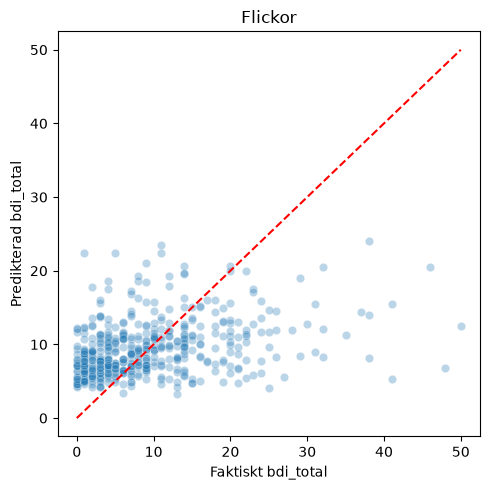

In [17]:
grid_flickor = train_and_evaluate(flickor[FEATURES], flickor[TARGET], "Flickor")

## Steg 9: Modell för pojkar

=== Pojkar ===
Bästa modell:         LinearRegression
Bästa inställningar:  {}
CV-RMSE (korsvalidering): 5.53
Test-RMSE: 5.34
Test-MAE:  3.68
Test-MSE:  28.50


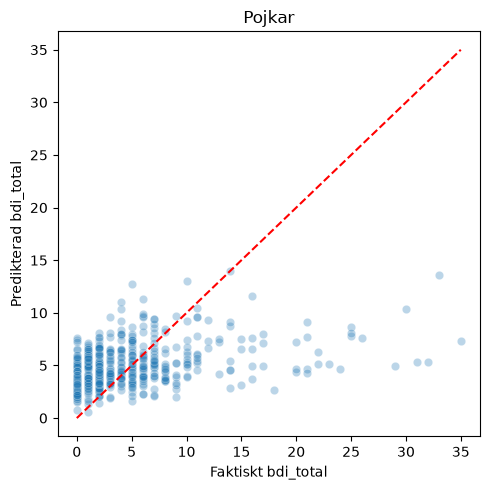

In [18]:
grid_pojkar = train_and_evaluate(pojkar[FEATURES], pojkar[TARGET], "Pojkar")

## Tolkning av utvärderingen: varför blir modellerna inte bättre?

**RMSE mot medelgissningen.** Test-RMSE hamnade på 8,16 (flickor) och 5,34 (pojkar), medan
standardavvikelsen i respektive grupp är 8,7 och 5,9. Att bara gissa varje persons
gruppmedelvärde ger alltså nästan lika litet fel – modellerna tillför väldigt lite
på individnivå.

**Korrelationen är verklig men liten – och den kvadreras.** För att räkna ut hur stor andel
av variationen ett samband förklarar tar man korrelationen i kvadrat (R²):

| Samband med BDI | Korrelation (r) | Förklarar (r²) |
|---|---|---|
| Sömnkvalitet | ~0,35 | ~12 % |
| Sömntimmar | ~−0,25 | ~6 % |
| Skärmtid | ~0,13 | ~1,7 % |

Alla sex variabler tillsammans förklarar ca **12–14 %** av variationen i BDI. Resten (85 %+)
beror på saker som inte finns med i datan: familj, vänner, skolstress, livshändelser m.m.

**Vad det betyder.** Sambanden är bra för att säga något om *gruppen* ("sämre sömn hänger
systematiskt ihop med högre BDI") men för svaga för att förutsäga en *enskild* persons värde.
Ingen modell kan lösa det: alla modeller omkombinerar bara samma sex kolumner, och om indata
bara "vet" ~15 % av storyn kan ingen algoritm hitta på resten. Därför landade alla modelltyper
som prövades (linjär regression, beslutsträd, random forest) inom ±0,2 RMSE av varandra.

## Steg 10: Test – hjälper polynomiala features?

Polynomiala features låter den linjära regressionen böja sig: modellen får rätta sig efter
kvadrater och kombinationer av variablerna, inte bara raka samband. Vi prövar grad 1–4 med
samma 5-fold korsvalidering som tidigare (grad 1 = vanlig linjär regression).

**Hypotes:** om sambanden i datan redan är nästan raka linjer borde extra grader bara ge
sämre resultat på ny data – mer flexibilitet utan mer signal betyder överanpassning.
Vi kollar först om det finns någon böjning i sambanden att fånga.

In [19]:
# Medel-BDI i fem lika stora grupper per variabel – visar om sambandet böjer sig
for kolumn in ["sleep_quality_index", "avg_sleep_hours", "est_leisure_screen_hours", "screen_time_index"]:
    grupper = pd.qcut(df[kolumn], 5, duplicates="drop")
    medel = df.groupby(grupper, observed=True)[TARGET].mean().round(1).tolist()
    print(f"{kolumn:28s}", medel)

sleep_quality_index          [4.5, 5.8, 7.3, 8.6, 12.8]
avg_sleep_hours              [10.4, 7.9, 6.9, 6.2, 4.9]
est_leisure_screen_hours     [6.3, 6.6, 7.5, 8.0, 8.6]
screen_time_index            [5.9, 7.1, 7.3, 8.2, 9.0]


In [20]:
def polynomial_test(X, y, namn, grader=(1, 2, 3, 4)):
    """Jämför polynomial regression (grad 1-4) med 5-fold korsvalidering."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])
    grid = GridSearchCV(pipeline, {"poly__degree": list(grader)}, cv=5,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X_train, y_train)

    print(f"=== {namn} ===")
    for i, grad in enumerate(grader):
        cv_rmse = -grid.cv_results_["mean_test_score"][i]
        antal = PolynomialFeatures(degree=grad, include_bias=False).fit(X_train).n_output_features_
        print(f"Grad {grad}: CV-RMSE {cv_rmse:.2f} ({antal} features)")
    y_pred = grid.predict(X_test)
    print(f"Bästa grad: {grid.best_params_['poly__degree']}")
    print(f"Test-RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")

polynomial_test(flickor[FEATURES], flickor[TARGET], "Flickor")
polynomial_test(pojkar[FEATURES], pojkar[TARGET], "Pojkar")

=== Flickor ===
Grad 1: CV-RMSE 7.96 (6 features)
Grad 2: CV-RMSE 8.07 (27 features)
Grad 3: CV-RMSE 8.20 (83 features)
Grad 4: CV-RMSE 10.29 (209 features)
Bästa grad: 1
Test-RMSE: 8.16


=== Pojkar ===
Grad 1: CV-RMSE 5.53 (6 features)
Grad 2: CV-RMSE 5.61 (27 features)
Grad 3: CV-RMSE 5.75 (83 features)
Grad 4: CV-RMSE 7.55 (209 features)
Bästa grad: 1
Test-RMSE: 5.34


**Resultat: nej – grad 1 vinner i båga segmenten.** Tabellen ovan visar varför: medel-BDI
stiger nästan rakt per intervall i alla variabler, så det finns ingen böjning för polynomen
att fånga. Varje högre grad gjorde korsvalideringen sämre (flickor 7,96 → 8,07 → 8,20 → 10,29;
pojkar 5,53 → 5,61 → 5,75 → 7,55), och vid grad 4 med 209 features syns överanpassningen tydligt.

Detta stärker tolkningen från utvärderingen: begränsningen är *hur mycket information*
variablerna bär (~12–14 % förklarat), inte *formeln* som används. Polynom ändrar formen på
sambandet, inte informationsmängden.

## Steg 11: Slutsatser

**Skillnad mellan flickor och pojkar**
- Flickorna har i genomsnitt klart högre BDI-poäng (**9,40** mot **5,22** för pojkarna) och en
  större spridning (std 8,7 mot 5,9). Andelen med `depressed = 1` är också högre bland flickor.
- Sömnvariablerna skiljer sig lite åt: flickorna sover i snitt kortare tid (7,59 mot 7,79 h)
  och har högre (dvs. sämre) sömnkvalitetsindex.

**Vad hänger ihop med BDI?**
- I **båda** segmenten är det sömnen som hänger starkast samman med BDI-poängen:
  sämre sömnkvalitet (korrelation ca **0,33–0,36**) och kortare sömn (ca **-0,25**) följer
  högre BDI.
- Skärmtiden har ett svagt positivt samband med BDI i båga grupperna (ca **0,11–0,14**) –
  alltså en tendens, men långt ifrån något starkt samband.

**Hur bra blir modellerna?**
- I båda segmenten valde `GridSearchCV` den **linjära regressionen** som bästa modell – de
  träd-baserade modellerna tillförde inget.
- Test-RMSE: **8,16** för flickor och **5,34** för pojkar – ungefär samma som
  standardavvikelsen i respektive grupp (8,7 respektive 5,9). Modellerna förklarar bara ca
  **12–14 %** av variationen (R²), alltså knappt bättre än att gissa gruppens medelvärde.
- Ett tilläggstest med **polynomiala features** (grad 1–4, steg 10) bekräftar bilden:
  korsvalideringen väljer grad 1 – sambanden är redan linjära, så formeln är inte problemet.

**Slutsats:** skärm- och sömnvariablerna visar statistiskt tydliga men **svaga** samband med
depressivitet, och räcker inte för att prediktera en individs BDI-poäng. Sömn är den mest
intressanta faktorn i båda grupperna, och flickor ligger generellt högre i BDI än pojkar.